#**DECISION TREE ALGORTIHM IMPLEMENTATION FROM SCRATCH AND IT'S COMPARISON WITH SKLEARN IMPLEMENTATION**

**IMPORTING REQUIRES LIBRARIES**

In [3]:
# Numerical and data handling libraries
import numpy as np
import pandas as pd
import math
from collections import Counter

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# For better plot style
sns.set(style="whitegrid")


**LOAD THE DATASET**

In [4]:
# Load dataset
df = pd.read_csv("breast-cancer.csv")

# Display first 5 rows
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**EDA**

In [5]:
print("Shape of dataset:", df.shape)
df.info()
#Shows number of rows, columns, and data types.


Shape of dataset: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14

**MISSING VALUES CHECK**

In [6]:
df.isnull().sum()


,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


no missing values - data is clean

**DIAGNOSIS DISTRIBUTION (VISUALIZATION)**

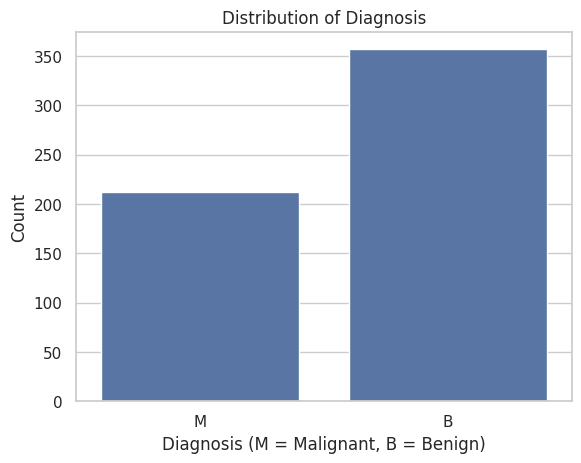

In [7]:
sns.countplot(x='diagnosis', data=df)
plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis (M = Malignant, B = Benign)")
plt.ylabel("Count")
plt.show()


the dataset is slightly imbalanced but can be used

**CORRELATION HEATMAP**

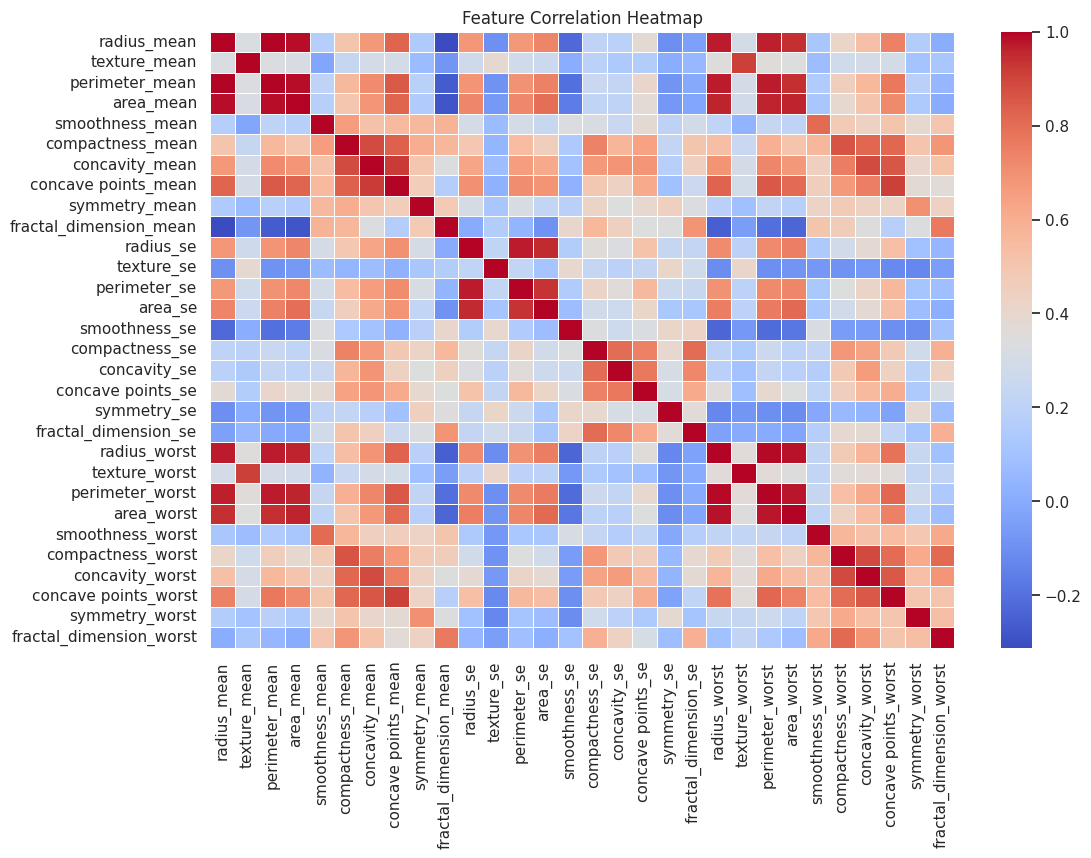

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('id', axis=1).corr(numeric_only=True), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

many features are correlated strongly hence decision tree is a better way to handle the dataset

**DATA PREPROCESSING**

dropping the irrelevant coloumns

In [9]:
# 'id' column has no predictive value
df.drop('id', axis=1, inplace=True)


encode the target variable

In [10]:
# Convert diagnosis labels to numeric
# M → 1 (Malignant), B → 0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


Feature target variable

In [11]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


manual train test split

In [12]:
def train_test_split_manual(X, y, test_size=0.2):
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split = int(len(X) * (1 - test_size))

    train_idx = indices[:split]
    test_idx = indices[split:]

    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]


X_train, X_test, y_train, y_test = train_test_split_manual(X, y)


**DECISION TREE IMPLEMENTATION FROM SCRATCH**

Entropy function

In [13]:
def entropy(y):
    """
    Calculate entropy of target variable
    """
    counts = Counter(y)
    total = len(y)
    ent = 0

    for count in counts.values():
        p = count / total
        ent -= p * math.log2(p)

    return ent


Information gain


In [14]:
def information_gain(X, y, feature):
    """
    Calculate information gain for a feature
    """
    parent_entropy = entropy(y)
    values = X[feature].unique()

    weighted_entropy = 0
    for val in values:
        subset_y = y[X[feature] == val]
        weighted_entropy += (len(subset_y) / len(y)) * entropy(subset_y)

    return parent_entropy - weighted_entropy


Build Decision Tree

In [15]:
def build_tree(X, y, features, depth=0, max_depth=4):
    """
    Recursive function to build decision tree
    """

    # If all labels are same → leaf node
    if len(set(y)) == 1:
        return y.iloc[0]

    # Stop condition
    if depth == max_depth or len(features) == 0:
        return Counter(y).most_common(1)[0][0]

    # Select best feature
    gains = [information_gain(X, y, f) for f in features]
    best_feature = features[gains.index(max(gains))]

    tree = {best_feature: {}}

    for value in X[best_feature].unique():
        sub_X = X[X[best_feature] == value]
        sub_y = y[X[best_feature] == value]

        remaining_features = features.copy()
        remaining_features.remove(best_feature)

        tree[best_feature][value] = build_tree(
            sub_X,
            sub_y,
            remaining_features,
            depth + 1,
            max_depth
        )

    return tree


Train the model

In [16]:
features = list(X_train.columns)
decision_tree = build_tree(X_train, y_train, features)

decision_tree


{'concavity_mean': {np.float64(0.07943): np.int64(0),
  np.float64(0.0695): np.int64(1),
  np.float64(0.01633): np.int64(0),
  np.float64(0.1793): np.int64(1),
  np.float64(0.1539): np.int64(1),
  np.float64(0.06843): np.int64(0),
  np.float64(0.0869): np.int64(1),
  np.float64(0.1659): np.int64(1),
  np.float64(0.08606): np.int64(0),
  np.float64(0.08259): np.int64(1),
  np.float64(0.3176): np.int64(1),
  np.float64(0.2256): np.int64(1),
  np.float64(0.05929): np.int64(0),
  np.float64(0.06651): np.int64(0),
  np.float64(0.08422): {'radius_mean': {np.float64(16.78): np.int64(1),
    np.float64(9.606): np.int64(0)}},
  np.float64(0.09042): np.int64(1),
  np.float64(0.06895): np.int64(0),
  np.float64(0.01171): np.int64(0),
  np.float64(0.09938): np.int64(1),
  np.float64(0.04515): np.int64(0),
  np.float64(0.03211): np.int64(0),
  np.float64(0.055): np.int64(0),
  np.float64(0.038): np.int64(0),
  np.float64(0.04751): np.int64(0),
  np.float64(0.1085): {'radius_mean': {np.float64(13.14

**PREDICTION FUNCTION**

In [17]:
def predict(tree, sample):
    """
    Predict class for a single data point
    """
    if not isinstance(tree, dict):
        return tree

    feature = next(iter(tree))
    value = sample[feature]

    if value in tree[feature]:
        return predict(tree[feature][value], sample)
    else:
        return 0


**MODEL EVALUATION**

In [18]:
y_pred = X_test.apply(lambda row: predict(decision_tree, row), axis=1)


**ACCURACY**

In [19]:
accuracy = np.mean(y_pred == y_test)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.7105263157894737


**CONFUSION MATRIX**

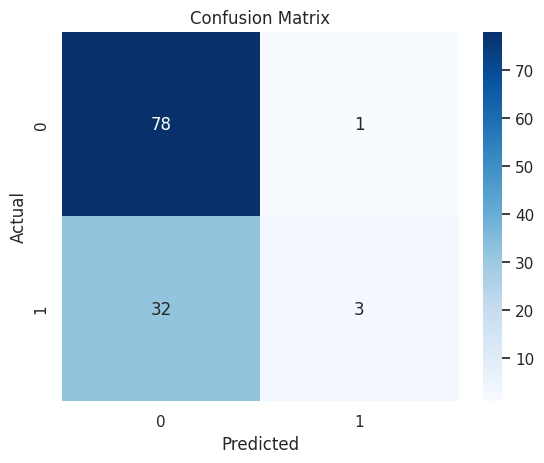

In [20]:
cm = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


**PREDICTION DISTRIBUTION**

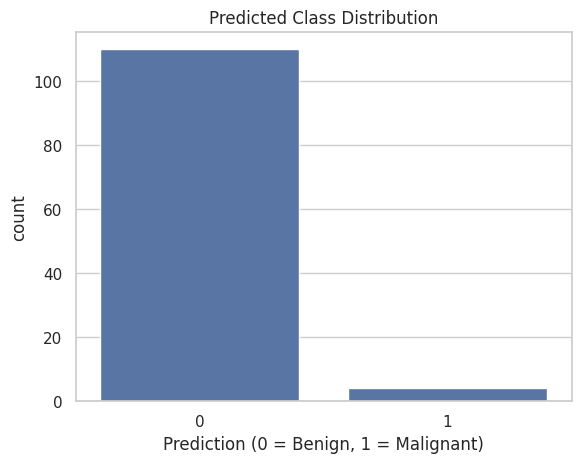

In [21]:
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution")
plt.xlabel("Prediction (0 = Benign, 1 = Malignant)")
plt.show()


**TREE PRINTING**

In [22]:
def print_tree(tree, depth=0):
    """
    Recursively prints the decision tree structure
    """
    if not isinstance(tree, dict):
        print("  " * depth + "➡ Prediction:", "Malignant" if tree == 1 else "Benign")
        return

    for feature, branches in tree.items():
        print("  " * depth + f"[Feature: {feature}]")

        for value, subtree in branches.items():
            print("  " * (depth + 1) + f"└── Value = {value}")
            print_tree(subtree, depth + 2)


In [23]:
print_tree(decision_tree)


[Feature: concavity_mean]
  └── Value = 0.07943
    ➡ Prediction: Benign
  └── Value = 0.0695
    ➡ Prediction: Malignant
  └── Value = 0.01633
    ➡ Prediction: Benign
  └── Value = 0.1793
    ➡ Prediction: Malignant
  └── Value = 0.1539
    ➡ Prediction: Malignant
  └── Value = 0.06843
    ➡ Prediction: Benign
  └── Value = 0.0869
    ➡ Prediction: Malignant
  └── Value = 0.1659
    ➡ Prediction: Malignant
  └── Value = 0.08606
    ➡ Prediction: Benign
  └── Value = 0.08259
    ➡ Prediction: Malignant
  └── Value = 0.3176
    ➡ Prediction: Malignant
  └── Value = 0.2256
    ➡ Prediction: Malignant
  └── Value = 0.05929
    ➡ Prediction: Benign
  └── Value = 0.06651
    ➡ Prediction: Benign
  └── Value = 0.08422
    [Feature: radius_mean]
      └── Value = 16.78
        ➡ Prediction: Malignant
      └── Value = 9.606
        ➡ Prediction: Benign
  └── Value = 0.09042
    ➡ Prediction: Malignant
  └── Value = 0.06895
    ➡ Prediction: Benign
  └── Value = 0.01171
    ➡ Prediction: Beni

**USING GRAPHIZ**

In [24]:
pip install graphviz


In [25]:
from graphviz import Digraph

def visualize_tree(tree):
    dot = Digraph()

    def add_nodes(tree, parent=None, edge_label=""):
        node_id = str(id(tree))

        if not isinstance(tree, dict):
            label = "Malignant" if tree == 1 else "Benign"
            dot.node(node_id, label, shape="box")
        else:
            feature = next(iter(tree))
            dot.node(node_id, feature)

            for value, subtree in tree[feature].items():
                child_id = str(id(subtree))
                add_nodes(subtree, node_id)
                dot.edge(node_id, child_id, label=str(value))

        return node_id

    add_nodes(tree)
    return dot


In [26]:
visualize_tree(decision_tree)


# **COMPARISON WITH SKLEARN TREE**

Importing required libraries

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix


**TRAIN SKLEARN DECISION TREE**

In [28]:
sk_model = DecisionTreeClassifier(
    criterion='entropy',   # Same as from scratch
    max_depth=4,
    random_state=42
)

sk_model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

why entropy ? - to keep the comparison fair with scratch tree

**SKLEARN PREDICTIONS**

In [29]:
y_pred_sk = sk_model.predict(X_test)


**SKLEARN ACCURACY**

In [30]:
accuracy_sklearn = accuracy_score(y_test, y_pred_sk)
print("Sklearn Decision Tree Accuracy:", accuracy_sklearn)


Sklearn Decision Tree Accuracy: 0.9736842105263158


**CONFUSION MATRIX COMPARISON**

FROM SCRATCH

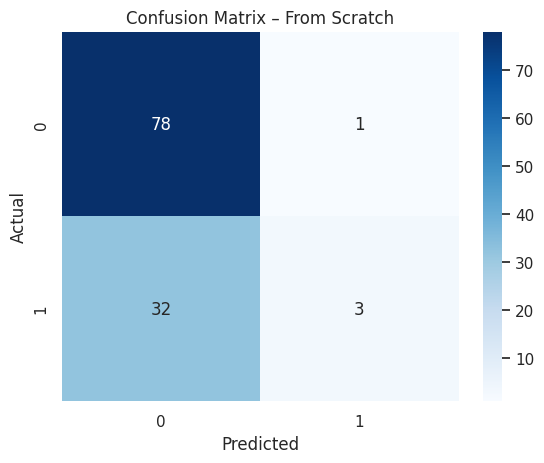

In [31]:
cm_scratch = pd.crosstab(
    y_test, y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – From Scratch")
plt.show()


SKLEARN

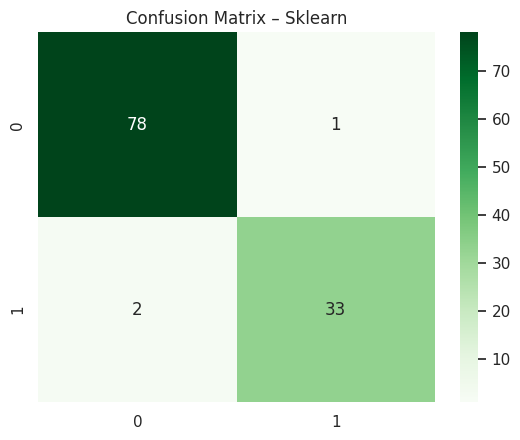

In [32]:
cm_sk = confusion_matrix(y_test, y_pred_sk)

sns.heatmap(cm_sk, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix – Sklearn")
plt.show()


**TREE VISUALIZATION**

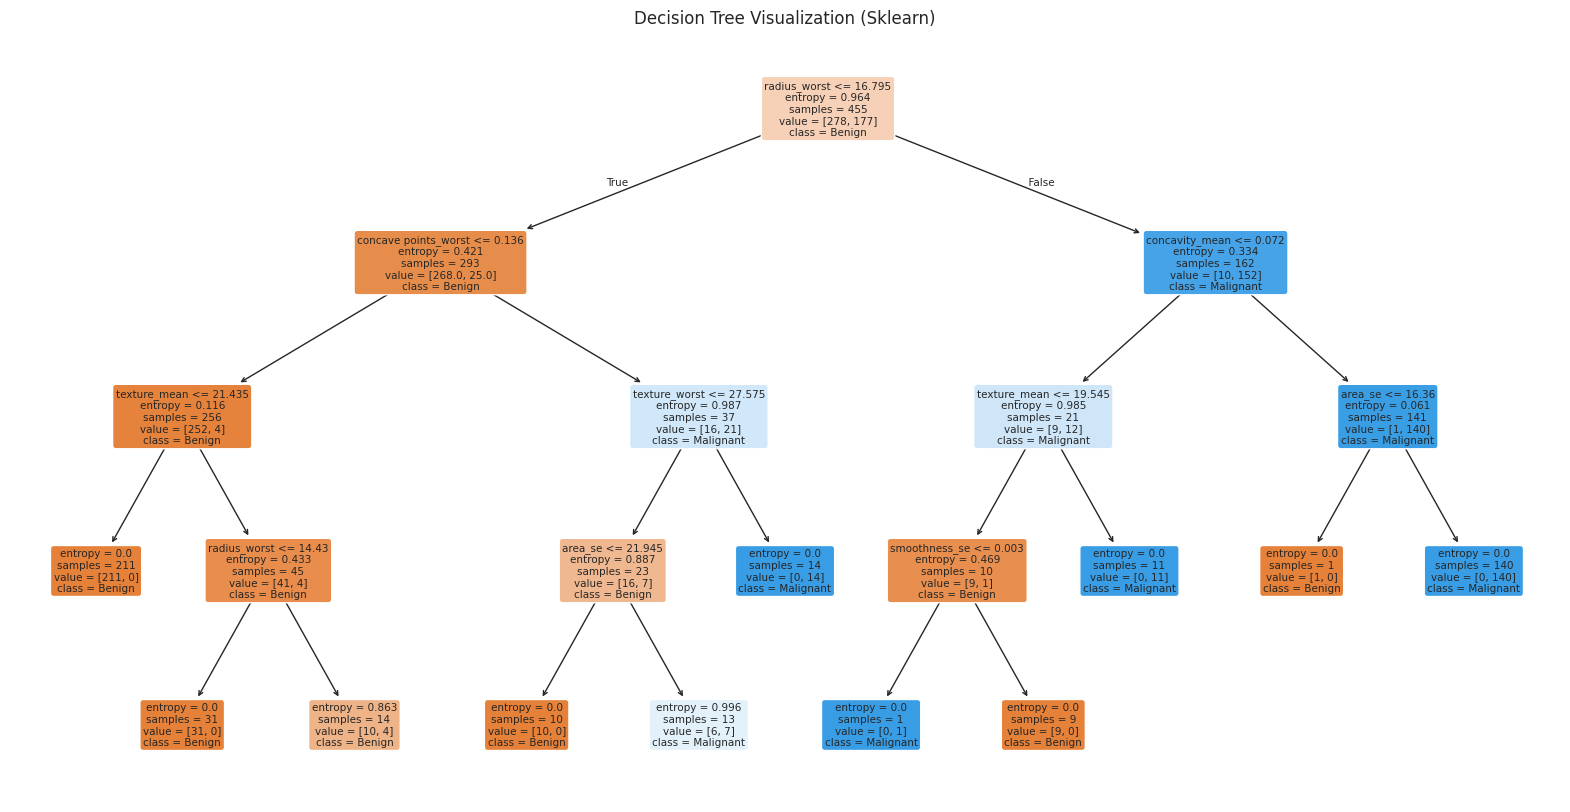

In [33]:
plt.figure(figsize=(20, 10))
plot_tree(
    sk_model,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization (Sklearn)")
plt.show()


**ACCURACY COMPARISON PLOT**

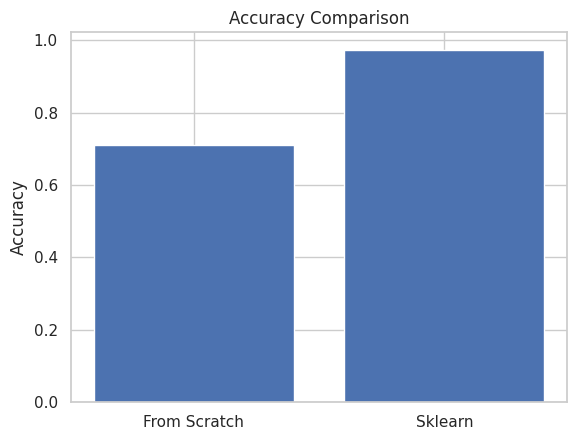

In [34]:
plt.bar(
    ["From Scratch", "Sklearn"],
    [accuracy, accuracy_sklearn]
)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()